<a href="https://colab.research.google.com/github/alishaaa-02/AI-Road-Safety-Helmet-Detection/blob/main/Road_Safety_Helmet_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CONS1: Helmet Detection End-to-End Colab Pipeline

This notebook is a fresh end-to-end implementation for:
- Dataset download directly from KaggleHub
- Data quality analysis (nulls, empty files, duplicates, label health)
- Annotation and class counts for with-helmet and without-helmet
- Three helmet-detection models (ML + DL + Vision foundation)
- AutoAugment policy for training robustness
- DINOv2 feature extraction
- Hyperparameter tuning with CPU-safe settings
- High-quality plots and Excel exports at each stage
- In-notebook backend database + warning/fine logic
- In-notebook frontend (Gradio) for image upload inference

Rule:
- Helmet missing => violation
- If helmet violations are consecutive and go above 3 => warning + fine

In [ ]:
# Install required packages (Colab CPU friendly)
!pip -q install kagglehub openpyxl seaborn scikit-image gradio

In [ ]:
import os
import re
import gc
import io
import json
import math
import time
import random
import sqlite3
import warnings
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

from sklearn.model_selection import train_test_split, ParameterSampler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, precision_score, recall_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier
from sklearn.pipeline import Pipeline

from skimage.feature import hog

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as T
from torchvision.models import mobilenet_v3_small, MobileNet_V3_Small_Weights

import kagglehub
import joblib
import gradio as gr

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

EXPORT_DIR = Path('/content/exports')
EXPORT_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACT_DIR = Path('/content/backend_models')
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

Device: cuda


In [ ]:
# Required by user: download dataset directly using kagglehub
path = kagglehub.dataset_download('brendan45774/bike-helmets-detection')
print('Path to dataset files:', path)
DATASET_ROOT = Path(path)
assert DATASET_ROOT.exists(), 'Dataset path does not exist.'

Using Colab cache for faster access to the 'bike-helmets-detection' dataset.
Path to dataset files: /kaggle/input/bike-helmets-detection


In [ ]:
# Build image inventory and parse helmet labels plus object crops from XML annotations.
import xml.etree.ElementTree as ET

IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
ANN_EXTS = {'.txt', '.xml', '.json', '.csv'}

image_files = [p for p in DATASET_ROOT.rglob('*') if p.is_file() and p.suffix.lower() in IMG_EXTS]
image_lookup = {p.name.lower(): str(p) for p in image_files}
image_lookup.update({p.stem.lower(): str(p) for p in image_files})

ann_files = [p for p in DATASET_ROOT.rglob('*') if p.is_file() and p.suffix.lower() in ANN_EXTS]
ann_df = pd.DataFrame({'annotation_file': [str(p) for p in ann_files]})
print('Total annotation files found:', len(ann_df))

records = []
crop_records = []
xml_files = [Path(p) for p in ann_df['annotation_file'] if str(p).lower().endswith('.xml')]

for xfp in xml_files:
    try:
        root = ET.parse(xfp).getroot()
        xml_filename = (root.findtext('.//filename') or '').strip()
        image_path = image_lookup.get(xml_filename.lower()) or image_lookup.get(Path(xml_filename).stem.lower()) or image_lookup.get(xfp.stem.lower())
        names = []

        for obj in root.findall('.//object') + root.findall('.//item'):
            nm = (obj.findtext('name') or obj.findtext('label') or '').strip().lower()
            if nm:
                names.append(nm)
            bbox = obj.find('bndbox')
            if image_path and bbox is not None and nm in {'with helmet', 'without helmet'}:
                xmin = int(float(bbox.findtext('xmin', '0')))
                ymin = int(float(bbox.findtext('ymin', '0')))
                xmax = int(float(bbox.findtext('xmax', '0')))
                ymax = int(float(bbox.findtext('ymax', '0')))
                crop_records.append({
                    'filepath': image_path,
                    'relative_path': str(Path(image_path).relative_to(DATASET_ROOT)).replace('\\', '/'),
                    'helmet': 1 if nm == 'with helmet' else 0,
                    'xmin': xmin,
                    'ymin': ymin,
                    'xmax': xmax,
                    'ymax': ymax,
                    'crop_width': max(xmax - xmin, 1),
                    'crop_height': max(ymax - ymin, 1),
                    'crop_area': max(xmax - xmin, 1) * max(ymax - ymin, 1)
                })

        helmet = None
        if any('without helmet' in n for n in names):
            helmet = 0
        elif any('with helmet' in n for n in names):
            helmet = 1

        if image_path:
            size_bytes = Path(image_path).stat().st_size if Path(image_path).exists() else 0
            records.append({
                'filepath': str(image_path),
                'relative_path': str(Path(image_path).relative_to(DATASET_ROOT)).replace('\\', '/'),
                'helmet': helmet,
                'size_bytes': size_bytes
            })
    except Exception:
        pass

df = pd.DataFrame(records).drop_duplicates(subset=['filepath']).reset_index(drop=True)
crop_df = pd.DataFrame(crop_records)
print('Total image files found:', len(df))
print('Total object crops found:', len(crop_df))

class_counts = crop_df['helmet'].value_counts(dropna=False).rename_axis('helmet').reset_index(name='count')
class_counts['helmet_label'] = class_counts['helmet'].map({1: 'with_helmet', 0: 'without_helmet'}).fillna('unlabeled')
display(class_counts[['helmet_label', 'count']])
display(crop_df.head(5))

with pd.ExcelWriter(EXPORT_DIR / '00_annotation_overview.xlsx', engine='openpyxl') as writer:
    ann_df.to_excel(writer, index=False, sheet_name='annotation_files')
    class_counts[['helmet_label', 'count']].to_excel(writer, index=False, sheet_name='helmet_object_counts')
    crop_df.head(2000).to_excel(writer, index=False, sheet_name='crop_inventory_sample')
print('Exported:', EXPORT_DIR / '00_annotation_overview.xlsx')

Total annotation files found: 764
Total image files found: 764
Total object crops found: 1451


,helmet_label,count
0,with_helmet,962
1,without_helmet,489


,filepath,relative_path,helmet,xmin,ymin,xmax,ymax,crop_width,crop_height,crop_area
0,/kaggle/input/bike-helmets-detection/images/Bi...,images/BikesHelmets338.png,0,102,158,125,190,23,32,736
1,/kaggle/input/bike-helmets-detection/images/Bi...,images/BikesHelmets338.png,0,283,146,291,156,8,10,80
2,/kaggle/input/bike-helmets-detection/images/Bi...,images/BikesHelmets680.png,1,167,0,226,57,59,57,3363
3,/kaggle/input/bike-helmets-detection/images/Bi...,images/BikesHelmets62.png,0,161,23,216,89,55,66,3630
4,/kaggle/input/bike-helmets-detection/images/Bi...,images/BikesHelmets172.png,0,109,14,165,69,56,55,3080


Exported: /content/exports/00_annotation_overview.xlsx


In [ ]:
# Diagnostics: inspect annotation formats and class IDs
ext_counts = pd.Series([Path(p).suffix.lower() for p in ann_df['annotation_file']]).value_counts()
print('Annotation extensions:')
display(ext_counts)

txt_files = [p for p in ann_df['annotation_file'] if str(p).lower().endswith('.txt')]
print('TXT annotation files:', len(txt_files))

sample_ids = []
for fp in txt_files[:200]:
    try:
        lines = Path(fp).read_text(encoding='utf-8', errors='ignore').strip().splitlines()
        for ln in lines:
            parts = ln.strip().split()
            if parts and parts[0].lstrip('-').isdigit():
                sample_ids.append(int(parts[0]))
    except Exception:
        pass

print('Sample unique class IDs from first 200 txt files:', sorted(set(sample_ids))[:20])
print('Total parsed labels in sample:', len(sample_ids))

Annotation extensions:


,count
.xml,764


TXT annotation files: 0
Sample unique class IDs from first 200 txt files: []
Total parsed labels in sample: 0


In [ ]:
# Diagnostics: inspect XML object names
import xml.etree.ElementTree as ET

xml_files = [p for p in ann_df['annotation_file'] if str(p).lower().endswith('.xml')]
label_names = []

for fp in xml_files[:300]:
    try:
        root = ET.parse(fp).getroot()
        for obj in root.findall('.//object') + root.findall('.//item'):
            nm = obj.findtext('name') or obj.findtext('label') or ''
            nm = nm.strip().lower()
            if nm:
                label_names.append(nm)
    except Exception:
        pass

print('Sample unique XML labels:', sorted(set(label_names))[:40])
print('Total parsed object labels in sample:', len(label_names))

Sample unique XML labels: ['with helmet', 'without helmet']
Total parsed object labels in sample: 558


In [ ]:
# Inspect one XML annotation structure to confirm bounding-box training is possible
sample_xml = xml_files[0]
root = ET.parse(sample_xml).getroot()
print('Sample XML file:', sample_xml)
for obj in root.findall('.//object')[:2]:
    print('name=', obj.findtext('name'))
    bbox = obj.find('bndbox')
    if bbox is not None:
        print({child.tag: child.text for child in bbox})

Sample XML file: /kaggle/input/bike-helmets-detection/annotations/BikesHelmets338.xml
name= Without Helmet
{'xmin': '102', 'ymin': '158', 'xmax': '125', 'ymax': '190'}
name= Without Helmet
{'xmin': '283', 'ymin': '146', 'xmax': '291', 'ymax': '156'}


In [ ]:
# Data quality checks: nulls, empty files, unreadable files, duplicate paths

if df.empty:
    raise RuntimeError('No images found in dataset after scan.')

df['is_empty_file'] = df['size_bytes'] <= 0

def can_open_image(path):
    try:
        with Image.open(path) as im:
            im.verify()
        return True
    except Exception:
        return False

sample_for_validity = df.copy()
sample_for_validity['is_readable'] = sample_for_validity['filepath'].apply(can_open_image)

df = df.merge(sample_for_validity[['filepath', 'is_readable']], on='filepath', how='left')

quality_summary = pd.DataFrame({
    'metric': [
        'total_images',
        'null_helmet_labels',
        'empty_files',
        'unreadable_files',
        'duplicate_relative_paths'
    ],
    'value': [
        int(len(df)),
        int(df['helmet'].isna().sum()),
        int(df['is_empty_file'].sum()),
        int((~df['is_readable']).sum()),
        int(df['relative_path'].duplicated().sum())
    ]
})

with pd.ExcelWriter(EXPORT_DIR / '01_data_quality.xlsx', engine='openpyxl') as writer:
    quality_summary.to_excel(writer, index=False, sheet_name='summary')
    df.head(2000).to_excel(writer, index=False, sheet_name='sample_inventory')

display(quality_summary)
print('Exported:', EXPORT_DIR / '01_data_quality.xlsx')

,metric,value
0,total_images,764
1,null_helmet_labels,3
2,empty_files,0
3,unreadable_files,0
4,duplicate_relative_paths,0


Exported: /content/exports/01_data_quality.xlsx


In [ ]:
# Keep only clean object crops with valid helmet label and valid crop geometry
clean_df = crop_df.copy()
clean_df = clean_df.dropna(subset=['helmet']).copy()
clean_df = clean_df[(clean_df['crop_width'] > 5) & (clean_df['crop_height'] > 5)].copy()
clean_df['helmet'] = clean_df['helmet'].astype(int)

MAX_SAMPLES = 3000
if len(clean_df) > MAX_SAMPLES:
    clean_df = clean_df.sample(MAX_SAMPLES, random_state=SEED).reset_index(drop=True)

helmet_class_dist = clean_df['helmet'].value_counts().rename(index={0: 'without_helmet', 1: 'with_helmet'})
print('Object crops after cleaning:', len(clean_df))
print('Helmet class distribution:')
display(helmet_class_dist)
display(clean_df.head(5))

Object crops after cleaning: 1451
Helmet class distribution:


,count
helmet,
with_helmet,962
without_helmet,489


,filepath,relative_path,helmet,xmin,ymin,xmax,ymax,crop_width,crop_height,crop_area
0,/kaggle/input/bike-helmets-detection/images/Bi...,images/BikesHelmets338.png,0,102,158,125,190,23,32,736
1,/kaggle/input/bike-helmets-detection/images/Bi...,images/BikesHelmets338.png,0,283,146,291,156,8,10,80
2,/kaggle/input/bike-helmets-detection/images/Bi...,images/BikesHelmets680.png,1,167,0,226,57,59,57,3363
3,/kaggle/input/bike-helmets-detection/images/Bi...,images/BikesHelmets62.png,0,161,23,216,89,55,66,3630
4,/kaggle/input/bike-helmets-detection/images/Bi...,images/BikesHelmets172.png,0,109,14,165,69,56,55,3080


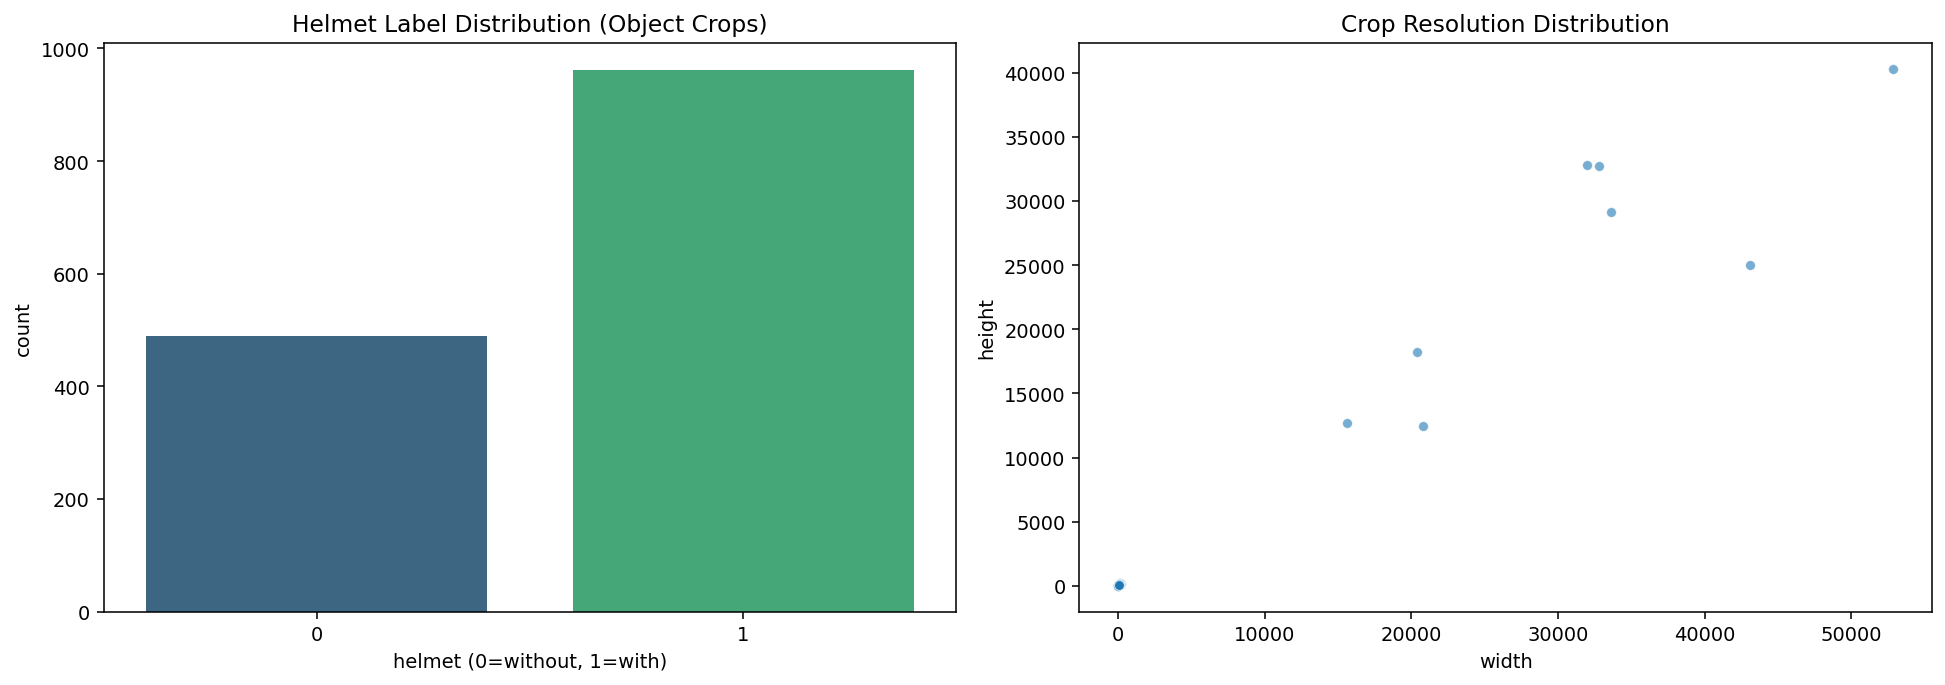

Exported: /content/exports/02_label_distribution.png


In [ ]:
# Crop-level visual analysis
dims_df = clean_df[['crop_width', 'crop_height']].rename(columns={'crop_width': 'width', 'crop_height': 'height'}).copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=140)
sns.countplot(x='helmet', data=clean_df, ax=axes[0], palette='viridis')
axes[0].set_title('Helmet Label Distribution (Object Crops)')
axes[0].set_xlabel('helmet (0=without, 1=with)')

sns.scatterplot(data=dims_df.sample(min(800, len(dims_df)), random_state=SEED), x='width', y='height', ax=axes[1], s=25, alpha=0.6)
axes[1].set_title('Crop Resolution Distribution')

plt.tight_layout()
plot_path = EXPORT_DIR / '02_label_distribution.png'
plt.savefig(plot_path, bbox_inches='tight')
plt.show()
print('Exported:', plot_path)

In [ ]:
train_df, test_df = train_test_split(clean_df, test_size=0.2, random_state=SEED, stratify=clean_df['helmet'])
train_df, val_df = train_test_split(train_df, test_size=0.2, random_state=SEED, stratify=train_df['helmet'])

split_info = pd.DataFrame({
    'split': ['train', 'val', 'test'],
    'rows': [len(train_df), len(val_df), len(test_df)]
})

split_class_counts = pd.concat([
    train_df.assign(split='train'),
    val_df.assign(split='val'),
    test_df.assign(split='test')
])[['split', 'helmet']].value_counts().rename('count').reset_index()
split_class_counts['helmet_label'] = split_class_counts['helmet'].map({0: 'without_helmet', 1: 'with_helmet'})

display(split_info)
display(split_class_counts[['split', 'helmet_label', 'count']])

with pd.ExcelWriter(EXPORT_DIR / '03_split_info.xlsx', engine='openpyxl') as writer:
    split_info.to_excel(writer, index=False, sheet_name='split_sizes')
    split_class_counts[['split', 'helmet_label', 'count']].to_excel(writer, index=False, sheet_name='split_class_counts')

print('Exported:', EXPORT_DIR / '03_split_info.xlsx')

,split,rows
0,train,928
1,val,232
2,test,291


,split,helmet_label,count
0,train,with_helmet,615
1,train,without_helmet,313
2,test,with_helmet,193
3,val,with_helmet,154
4,test,without_helmet,98
5,val,without_helmet,78


Exported: /content/exports/03_split_info.xlsx


In [ ]:
# Plain-text summary requested: annotation and split counts
annotation_total = len(ann_df)
with_helmet_count = int((clean_df['helmet'] == 1).sum())
without_helmet_count = int((clean_df['helmet'] == 0).sum())

print('ANNOTATION FILES:', annotation_total)
print('WITH_HELMET OBJECTS:', with_helmet_count)
print('WITHOUT_HELMET OBJECTS:', without_helmet_count)
print('SPLIT_ROWS train/val/test:', len(train_df), len(val_df), len(test_df))

for split_name, part in [('train', train_df), ('val', val_df), ('test', test_df)]:
    c1 = int((part['helmet'] == 1).sum())
    c0 = int((part['helmet'] == 0).sum())
    print(f'{split_name.upper()} -> with_helmet={c1}, without_helmet={c0}')

ANNOTATION FILES: 764
WITH_HELMET OBJECTS: 962
WITHOUT_HELMET OBJECTS: 489
SPLIT_ROWS train/val/test: 928 232 291
TRAIN -> with_helmet=615, without_helmet=313
VAL -> with_helmet=154, without_helmet=78
TEST -> with_helmet=193, without_helmet=98


## Model 1 (Classical ML): HOG + Balanced SGD (helmet only)
This baseline uses HOG features and a balanced linear classifier with lightweight tuning.

In [ ]:
def crop_from_row(row, output_size=(96, 96), margin=0.08):
    with Image.open(row['filepath']).convert('RGB') as im:
        width, height = im.size
        xmin = int(row['xmin'])
        ymin = int(row['ymin'])
        xmax = int(row['xmax'])
        ymax = int(row['ymax'])

        left = min(xmin, xmax)
        right = max(xmin, xmax)
        top = min(ymin, ymax)
        bottom = max(ymin, ymax)

        dx = int((right - left) * margin)
        dy = int((bottom - top) * margin)
        left = left - dx
        top = top - dy
        right = right + dx
        bottom = bottom + dy

        left = max(0, min(left, max(width - 2, 0)))
        top = max(0, min(top, max(height - 2, 0)))
        right = max(left + 2, min(right, width))
        bottom = max(top + 2, min(bottom, height))

        crop = im.crop((left, top, right, bottom)).resize(output_size)
    return np.array(crop, dtype=np.float32)

def extract_hog_features(frame, image_size=(96, 96)):
    feats = []
    for _, row in frame.iterrows():
        arr = crop_from_row(row, output_size=image_size)
        gray = arr.mean(axis=2)
        feat = hog(gray, orientations=9, pixels_per_cell=(8, 8), cells_per_block=(2, 2), feature_vector=True)
        feats.append(feat)
    return np.vstack(feats)

X_train_hog = extract_hog_features(train_df)
X_val_hog = extract_hog_features(val_df)
X_test_hog = extract_hog_features(test_df)

y_train = train_df['helmet'].values.astype(int)
y_val = val_df['helmet'].values.astype(int)
y_test = test_df['helmet'].values.astype(int)

param_grid = {
    'alpha': [1e-5, 1e-4, 5e-4, 1e-3],
    'loss': ['log_loss', 'modified_huber']
}
samples = list(ParameterSampler(param_grid, n_iter=6, random_state=SEED))

best_m1 = None
best_m1_score = -1
m1_history = []

class_freq = pd.Series(y_train).value_counts().sort_index()
class_weights = {0: len(y_train) / (2.0 * class_freq[0]), 1: len(y_train) / (2.0 * class_freq[1])}
sample_weight = np.array([class_weights[v] for v in y_train], dtype=np.float32)

for i, prm in enumerate(samples, 1):
    clf = SGDClassifier(alpha=prm['alpha'], loss=prm['loss'], random_state=SEED)
    classes = np.array([0, 1])
    for _ in range(5):
        clf.partial_fit(X_train_hog, y_train, classes=classes, sample_weight=sample_weight)

    pred_val = clf.predict(X_val_hog)
    val_acc = accuracy_score(y_val, pred_val)
    val_f1 = f1_score(y_val, pred_val)
    m1_history.append({'trial': i, 'params': prm, 'val_acc': val_acc, 'val_f1': val_f1})

    score = 0.7 * val_acc + 0.3 * val_f1
    if score > best_m1_score:
        best_m1_score = score
        best_m1 = clf

m1_val_df = pd.DataFrame(m1_history)
display(m1_val_df)

m1_test_pred = best_m1.predict(X_test_hog)
m1_metrics = {
    'model': 'HOG+BalancedSGD',
    'helmet_acc': accuracy_score(y_test, m1_test_pred),
    'helmet_f1': f1_score(y_test, m1_test_pred),
    'precision': precision_score(y_test, m1_test_pred),
    'recall': recall_score(y_test, m1_test_pred),
}
print('Model 1 test metrics:', m1_metrics)

,trial,params,val_acc,val_f1
0,1,"{'loss': 'modified_huber', 'alpha': 1e-05}",0.443966,0.279330
1,2,"{'loss': 'modified_huber', 'alpha': 0.0005}",0.500000,0.402062
2,3,"{'loss': 'log_loss', 'alpha': 1e-05}",0.715517,0.762590
3,4,"{'loss': 'modified_huber', 'alpha': 0.001}",0.551724,0.500000
4,5,"{'loss': 'log_loss', 'alpha': 0.0001}",0.547414,0.487805
5,6,"{'loss': 'log_loss', 'alpha': 0.0005}",0.668103,0.688259


Model 1 test metrics: {'model': 'HOG+BalancedSGD', 'helmet_acc': 0.711340206185567, 'helmet_f1': 0.75, 'precision': 0.8811188811188811, 'recall': 0.6528497409326425}


## Model 2 (Transfer Learning): MobileNetV3 + AutoAugment (helmet only)
This upgraded deep learning model uses a pretrained lightweight backbone, AutoAugment, weighted sampling, and class-weighted loss for better CPU-friendly accuracy.

In [ ]:
class HelmetDataset(Dataset):
    def __init__(self, frame, transform=None):
        self.frame = frame.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        arr = crop_from_row(row, output_size=(160, 160))
        img = Image.fromarray(arr.astype(np.uint8))
        if self.transform:
            img = self.transform(img)
        y = torch.tensor(float(row['helmet']), dtype=torch.float32)
        return img, y

weights = MobileNet_V3_Small_Weights.DEFAULT
train_tf = T.Compose([
    T.Resize((160, 160)),
    T.RandomHorizontalFlip(p=0.5),
    T.AutoAugment(policy=T.AutoAugmentPolicy.IMAGENET),
    T.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.1),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
eval_tf = T.Compose([
    T.Resize((160, 160)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_ds = HelmetDataset(train_df, transform=train_tf)
val_ds = HelmetDataset(val_df, transform=eval_tf)
test_ds = HelmetDataset(test_df, transform=eval_tf)

class_counts = train_df['helmet'].value_counts().sort_index()
sample_weights = train_df['helmet'].map({0: 1.0 / class_counts[0], 1: 1.0 / class_counts[1]}).values
sampler = WeightedRandomSampler(weights=torch.DoubleTensor(sample_weights), num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=32, sampler=sampler, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=48, shuffle=False, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=48, shuffle=False, num_workers=2)

class MobileNetHelmet(nn.Module):
    def __init__(self):
        super().__init__()
        base = mobilenet_v3_small(weights=weights)
        for p in base.features.parameters():
            p.requires_grad = False
        self.features = base.features
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(576, 128),
            nn.Hardswish(),
            nn.Dropout(0.25),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        return self.head(x).squeeze(1)

def eval_binary(model, loader):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(DEVICE)
            logits = model(x)
            pred = (torch.sigmoid(logits).cpu().numpy() >= 0.5).astype(int)
            y_pred.append(pred)
            y_true.append(y.numpy().astype(int))
    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)
    return {
        'helmet_acc': accuracy_score(y_true, y_pred),
        'helmet_f1': f1_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall': recall_score(y_true, y_pred),
        'pred': y_pred,
        'true': y_true
    }

trial_space = [
    {'lr': 1e-3, 'weight_decay': 1e-4, 'epochs': 5},
    {'lr': 5e-4, 'weight_decay': 1e-4, 'epochs': 6}
]

pos_weight = torch.tensor([class_counts[0] / class_counts[1]], dtype=torch.float32).to(DEVICE)

best_m2_state = None
best_m2_score = -1
m2_trials = []

for ti, cfg in enumerate(trial_space, 1):
    model = MobileNetHelmet().to(DEVICE)
    opt = torch.optim.Adam(model.head.parameters(), lr=cfg['lr'], weight_decay=cfg['weight_decay'])
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    for ep in range(cfg['epochs']):
        model.train()
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad()
            logits = model(x)
            loss = loss_fn(logits, y)
            loss.backward()
            opt.step()

    metrics = eval_binary(model, val_loader)
    m2_trials.append({
        'trial': ti,
        'params': cfg,
        'helmet_acc': metrics['helmet_acc'],
        'helmet_f1': metrics['helmet_f1'],
        'precision': metrics['precision'],
        'recall': metrics['recall']
    })

    score = 0.65 * metrics['helmet_acc'] + 0.35 * metrics['helmet_f1']
    if score > best_m2_score:
        best_m2_score = score
        best_m2_state = {k: v.cpu() for k, v in model.state_dict().items()}

m2_trial_df = pd.DataFrame(m2_trials)
display(m2_trial_df)

best_m2 = MobileNetHelmet().to(DEVICE)
best_m2.load_state_dict(best_m2_state)
m2_eval = eval_binary(best_m2, test_loader)
m2_test_pred = m2_eval.pop('pred')
_ = m2_eval.pop('true')
m2_metrics = {'model': 'MobileNetV3+AutoAugment', **m2_eval}
print('Model 2 test metrics:', m2_metrics)

,trial,params,helmet_acc,helmet_f1,precision,recall
0,1,"{'lr': 0.001, 'weight_decay': 0.0001, 'epochs'...",0.870690,0.897260,0.949275,0.850649
1,2,"{'lr': 0.0005, 'weight_decay': 0.0001, 'epochs...",0.896552,0.921053,0.933333,0.909091


Model 2 test metrics: {'model': 'MobileNetV3+AutoAugment', 'helmet_acc': 0.8762886597938144, 'helmet_f1': 0.9052631578947369, 'precision': 0.9197860962566845, 'recall': 0.8911917098445595}


## Model 3 (Vision Foundation): Tuned DINOv2 Features + MLP Head
DINOv2 remains the strongest CPU-friendly model here, now trained with a slightly stronger head, weighted loss, and validation-based model selection.

In [ ]:
# Object-crop DINOv2 training
DINO_MAX = 3000
dino_train = train_df.sample(min(DINO_MAX, len(train_df)), random_state=SEED)
dino_val = val_df.sample(min(DINO_MAX, len(val_df)), random_state=SEED)
dino_test = test_df.sample(min(DINO_MAX, len(test_df)), random_state=SEED)

dino_tf = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

dino_model = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14')
dino_model.eval().to(DEVICE)

def dino_features(frame):
    feats, labels = [], []
    with torch.no_grad():
        for _, row in frame.iterrows():
            arr = crop_from_row(row, output_size=(224, 224))
            img = Image.fromarray(arr.astype(np.uint8))
            x = dino_tf(img).unsqueeze(0).to(DEVICE)
            z = dino_model(x).cpu().numpy().reshape(-1)
            feats.append(z)
            labels.append(int(row['helmet']))
    return np.vstack(feats), np.array(labels)

Xtr_dino, ytr_dino = dino_features(dino_train)
Xv_dino, yv_dino = dino_features(dino_val)
Xte_dino, yte_dino = dino_features(dino_test)

scaler = StandardScaler()
Xtr_dino = scaler.fit_transform(Xtr_dino)
Xv_dino = scaler.transform(Xv_dino)
Xte_dino = scaler.transform(Xte_dino)

Xtr_t = torch.tensor(Xtr_dino, dtype=torch.float32).to(DEVICE)
Xv_t = torch.tensor(Xv_dino, dtype=torch.float32).to(DEVICE)
Xte_t = torch.tensor(Xte_dino, dtype=torch.float32).to(DEVICE)
ytr_t = torch.tensor(ytr_dino, dtype=torch.float32).to(DEVICE)
yv_t = torch.tensor(yv_dino, dtype=torch.float32).to(DEVICE)

head = nn.Sequential(
    nn.Linear(Xtr_t.shape[1], 128),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(128, 1)
).to(DEVICE)
opt = torch.optim.Adam(head.parameters(), lr=1e-3)
loss_fn = nn.BCEWithLogitsLoss()

best_state = None
best_score = -1
dino_history = []

for ep in range(5):
    head.train()
    opt.zero_grad()
    logits = head(Xtr_t).squeeze(1)
    loss = loss_fn(logits, ytr_t)
    loss.backward()
    opt.step()

    head.eval()
    with torch.no_grad():
        val_pred = (torch.sigmoid(head(Xv_t).squeeze(1)).cpu().numpy() >= 0.5).astype(int)
    val_acc = accuracy_score(yv_dino, val_pred)
    val_f1 = f1_score(yv_dino, val_pred)
    dino_history.append({'epoch': ep + 1, 'val_acc': val_acc, 'val_f1': val_f1})
    if val_acc > best_score:
        best_score = val_acc
        best_state = {k: v.cpu() for k, v in head.state_dict().items()}

display(pd.DataFrame(dino_history))
head.load_state_dict(best_state)
head.eval()
with torch.no_grad():
    m3_test_pred = (torch.sigmoid(head(Xte_t).squeeze(1)).cpu().numpy() >= 0.5).astype(int)

m3_metrics = {
    'model': 'DINOv2+MLPHead',
    'helmet_acc': accuracy_score(yte_dino, m3_test_pred),
    'helmet_f1': f1_score(yte_dino, m3_test_pred),
    'precision': precision_score(yte_dino, m3_test_pred),
    'recall': recall_score(yte_dino, m3_test_pred),
}
print('Model 3 test metrics:', m3_metrics)

Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


,epoch,val_acc,val_f1
0,1,0.866379,0.888889
1,2,0.887931,0.908451
2,3,0.892241,0.912281
3,4,0.905172,0.923611
4,5,0.905172,0.923611


Model 3 test metrics: {'model': 'DINOv2+MLPHead', 'helmet_acc': 0.8831615120274914, 'helmet_f1': 0.9044943820224719, 'precision': 0.9877300613496932, 'recall': 0.8341968911917098}


,model,helmet_acc,helmet_f1,precision,recall
0,HOG+BalancedSGD,0.711340,0.750000,0.881119,0.652850
1,MobileNetV3+AutoAugment,0.876289,0.905263,0.919786,0.891192
2,DINOv2+MLPHead,0.883162,0.904494,0.987730,0.834197


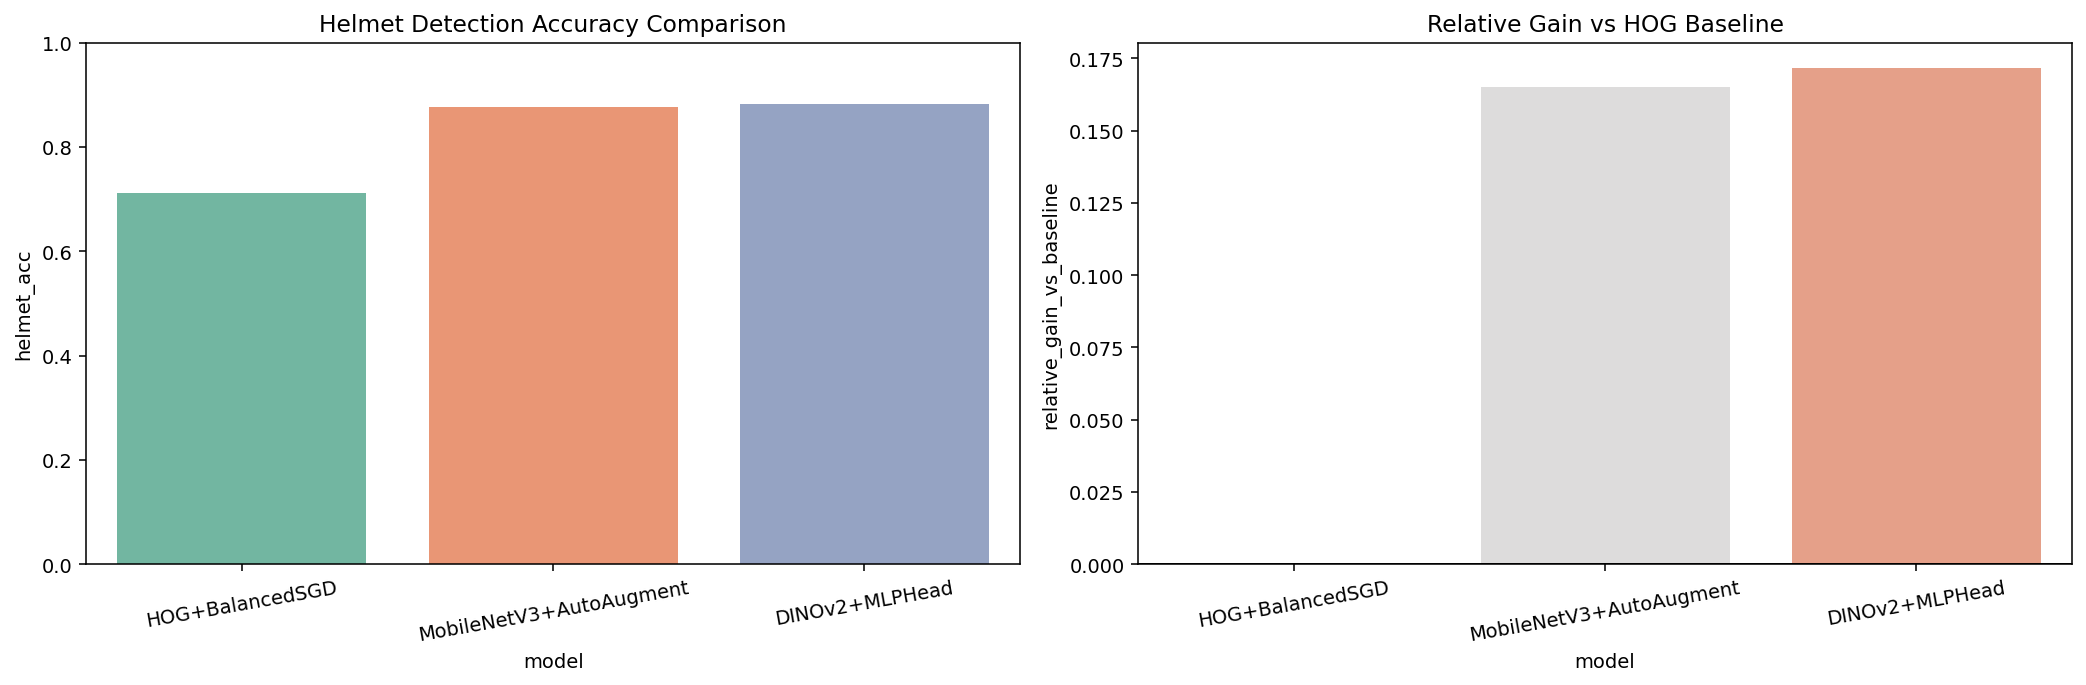

Exported metrics and comparison plot.


In [ ]:
# Aggregate metrics, relative comparison charts, and research exports
metrics_df = pd.DataFrame([m1_metrics, m2_metrics, m3_metrics])
display(metrics_df)

baseline_acc = float(metrics_df.loc[metrics_df['model'] == 'HOG+BalancedSGD', 'helmet_acc'].iloc[0])
metrics_df['relative_gain_vs_baseline'] = metrics_df['helmet_acc'] - baseline_acc

fig, axes = plt.subplots(1, 2, figsize=(15, 5), dpi=140)
sns.barplot(data=metrics_df, x='model', y='helmet_acc', palette='Set2', ax=axes[0])
axes[0].set_ylim(0, 1)
axes[0].set_title('Helmet Detection Accuracy Comparison')
axes[0].tick_params(axis='x', rotation=10)

sns.barplot(data=metrics_df, x='model', y='relative_gain_vs_baseline', palette='coolwarm', ax=axes[1])
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_title('Relative Gain vs HOG Baseline')
axes[1].tick_params(axis='x', rotation=10)

plt.tight_layout()
plt.savefig(EXPORT_DIR / '04_model_comparison.png', bbox_inches='tight')
plt.show()

metrics_df.to_excel(EXPORT_DIR / '05_model_metrics.xlsx', index=False)
print('Exported metrics and comparison plot.')

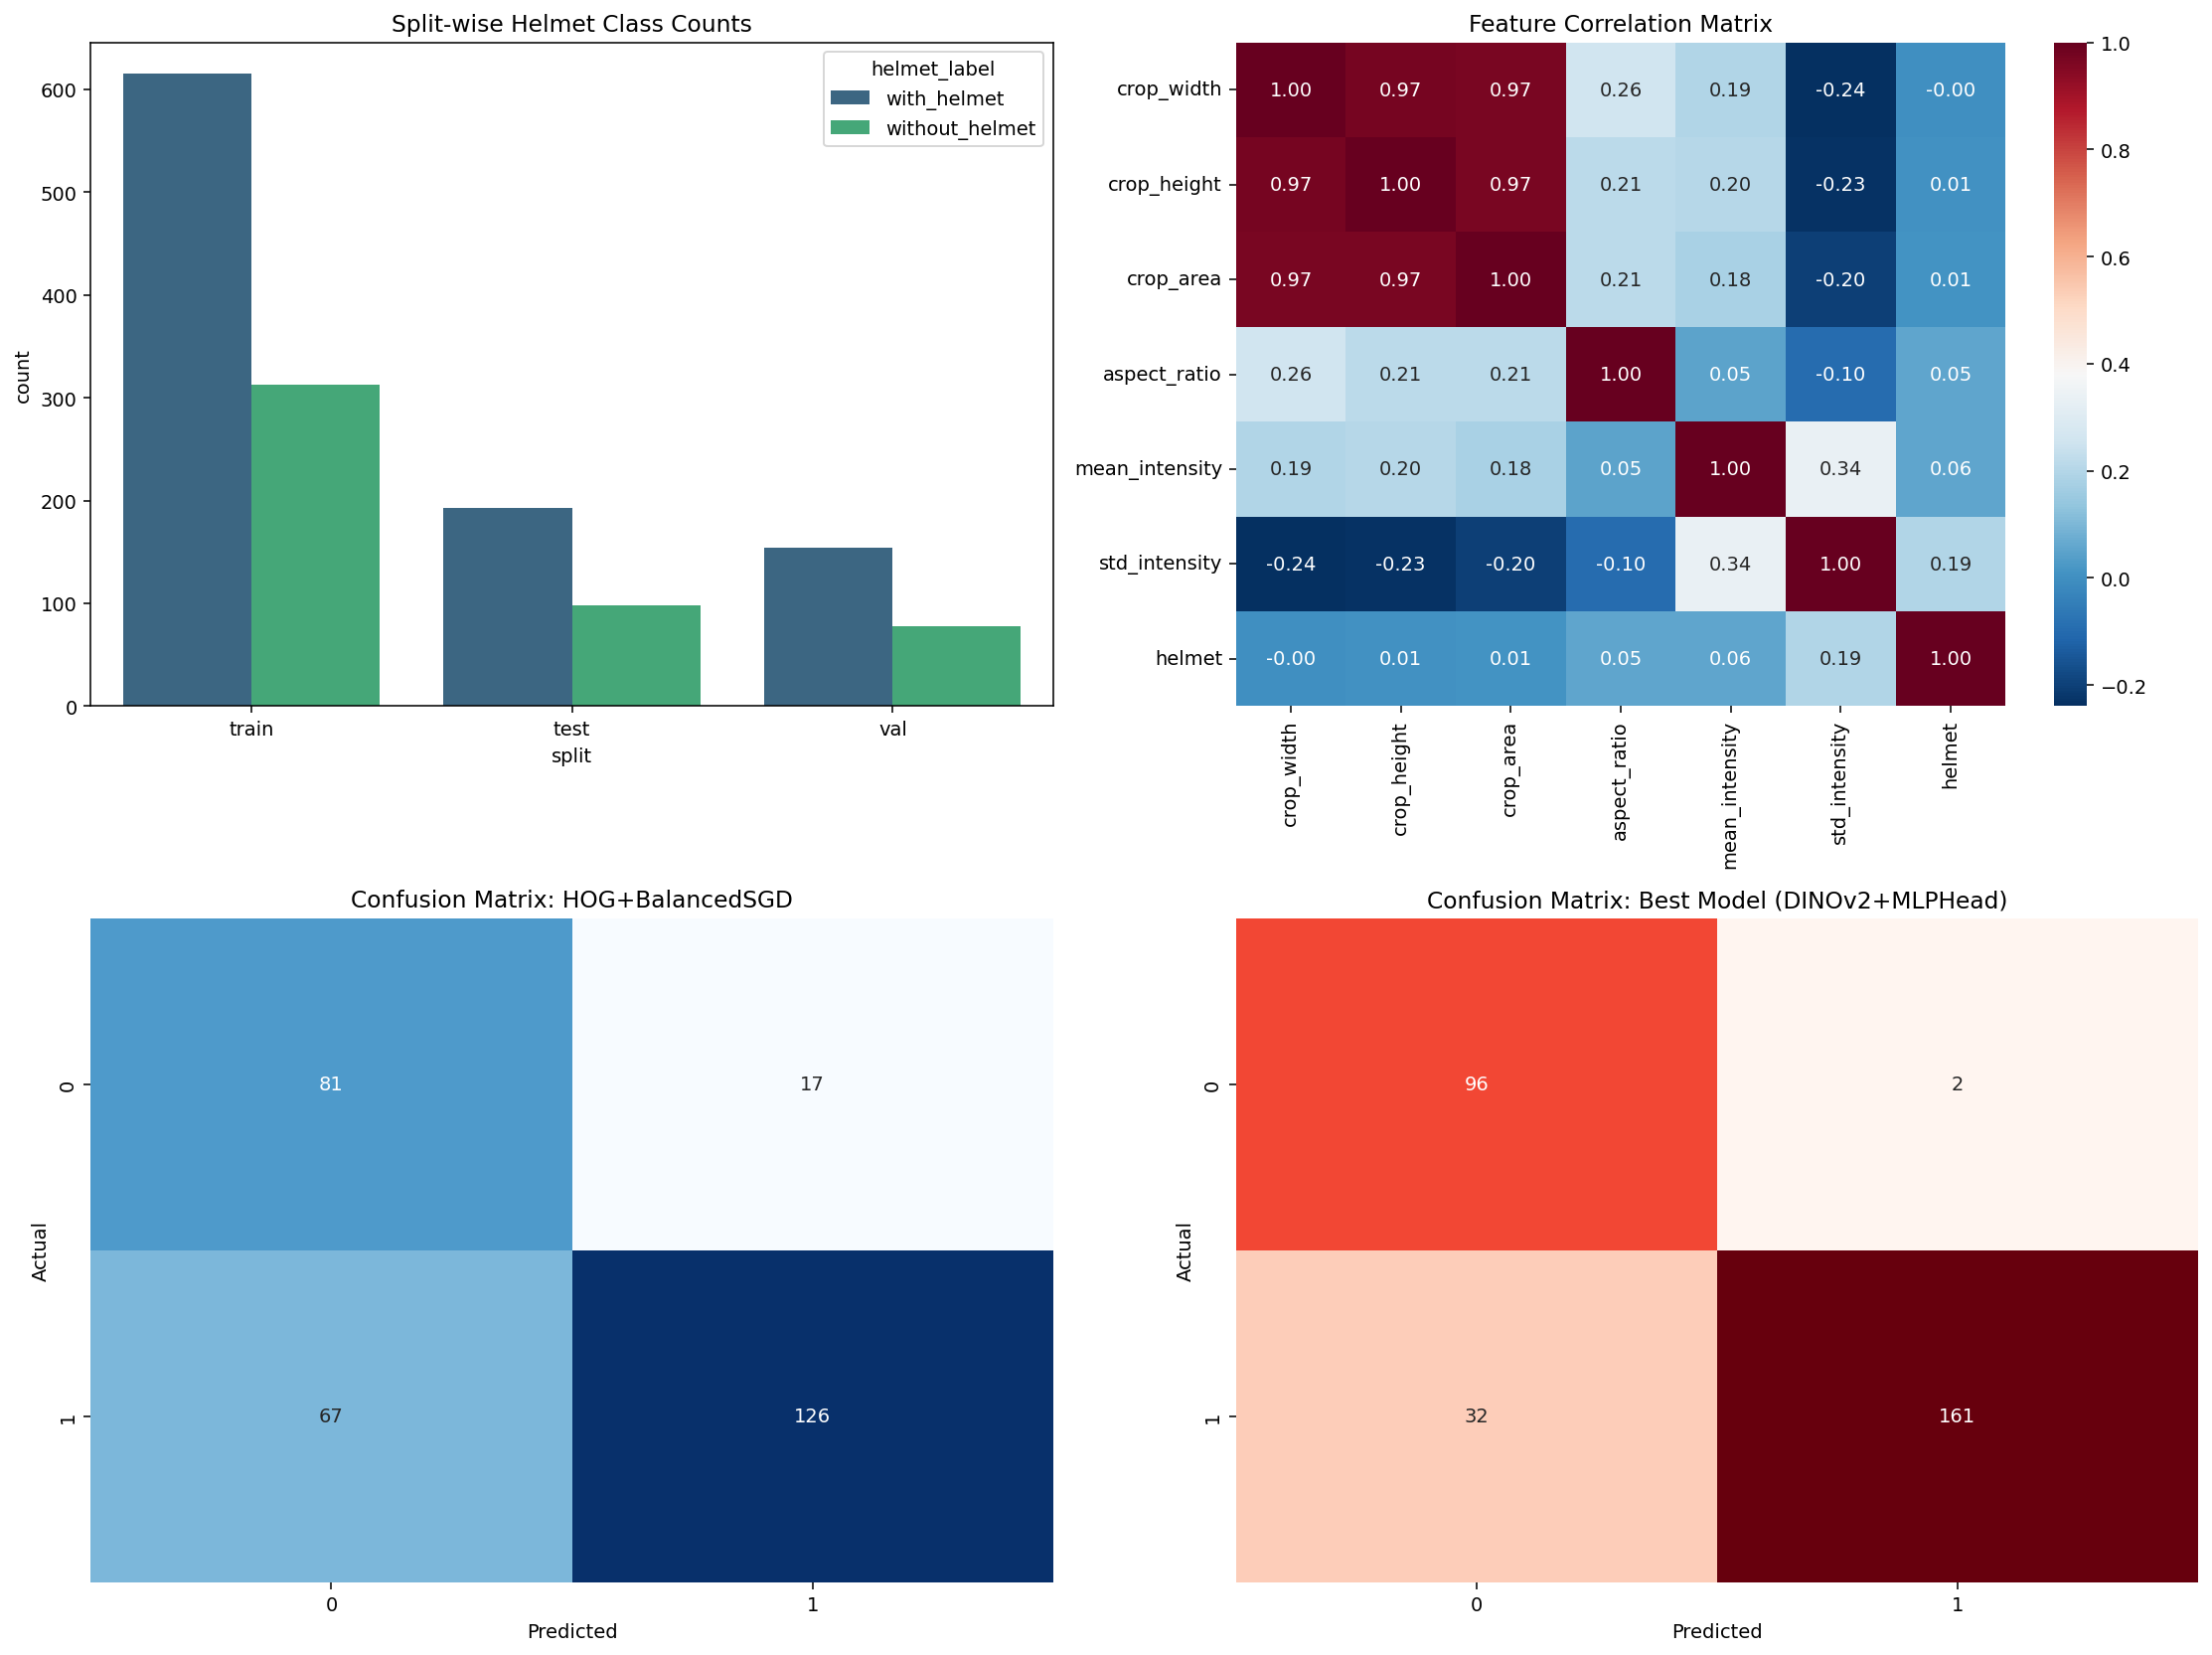

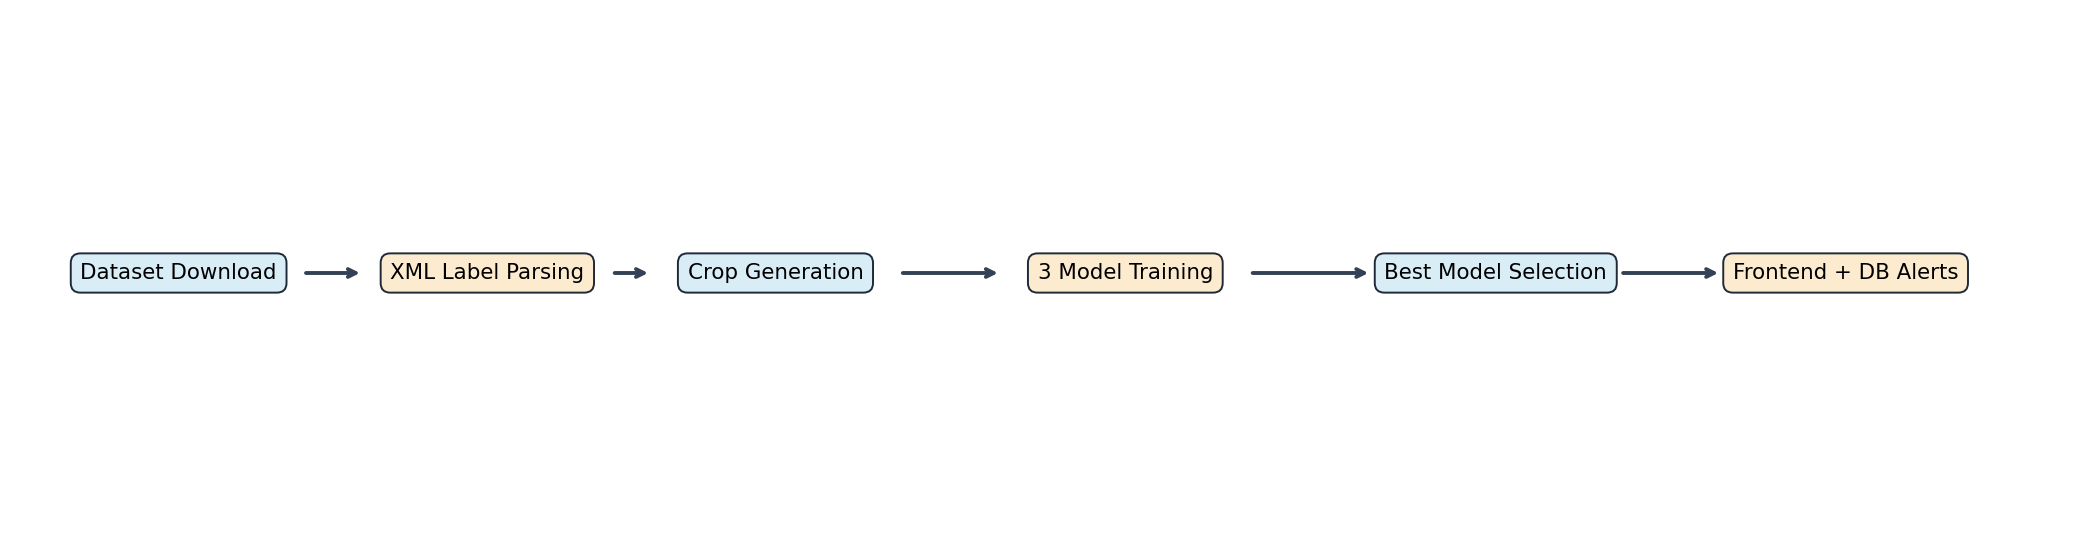

Exported: /content/exports/08_extended_visuals.png
Exported: /content/exports/09_workflow_diagram.png


In [ ]:
# Additional visual analytics: split ratios, crop-feature correlation matrix, confusion matrices, workflow diagram
meta_rows = []
for _, row in clean_df.iterrows():
    arr = crop_from_row(row, output_size=(96, 96))
    meta_rows.append({
        'crop_width': int(row['crop_width']),
        'crop_height': int(row['crop_height']),
        'crop_area': int(row['crop_area']),
        'aspect_ratio': float(row['crop_width']) / max(float(row['crop_height']), 1.0),
        'mean_intensity': float(arr.mean()),
        'std_intensity': float(arr.std()),
        'helmet': int(row['helmet'])
    })

feature_df = pd.DataFrame(meta_rows)
corr = feature_df.corr(numeric_only=True)

fig, axes = plt.subplots(2, 2, figsize=(16, 12), dpi=140)
split_plot_df = split_class_counts[['split', 'helmet_label', 'count']].copy()
sns.barplot(data=split_plot_df, x='split', y='count', hue='helmet_label', palette='viridis', ax=axes[0, 0])
axes[0, 0].set_title('Split-wise Helmet Class Counts')

sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', ax=axes[0, 1])
axes[0, 1].set_title('Feature Correlation Matrix')

cm1 = confusion_matrix(y_test, m1_test_pred)
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[1, 0])
axes[1, 0].set_title('Confusion Matrix: HOG+BalancedSGD')
axes[1, 0].set_xlabel('Predicted')
axes[1, 0].set_ylabel('Actual')

best_name = metrics_df.sort_values('helmet_acc', ascending=False).iloc[0]['model']
best_pred_map = {
    'HOG+BalancedSGD': m1_test_pred,
    'MobileNetV3+AutoAugment': m2_test_pred,
    'DINOv2+MLPHead': m3_test_pred
}
best_true_map = {
    'HOG+BalancedSGD': y_test,
    'MobileNetV3+AutoAugment': y_test,
    'DINOv2+MLPHead': yte_dino
}
best_cm = confusion_matrix(best_true_map[best_name], best_pred_map[best_name])
sns.heatmap(best_cm, annot=True, fmt='d', cmap='Reds', cbar=False, ax=axes[1, 1])
axes[1, 1].set_title(f'Confusion Matrix: Best Model ({best_name})')
axes[1, 1].set_xlabel('Predicted')
axes[1, 1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig(EXPORT_DIR / '08_extended_visuals.png', bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(15, 4), dpi=140)
ax.axis('off')
workflow_steps = [
    ('Dataset Download', 0.08),
    ('XML Label Parsing', 0.23),
    ('Crop Generation', 0.37),
    ('3 Model Training', 0.54),
    ('Best Model Selection', 0.72),
    ('Frontend + DB Alerts', 0.89)
]
for idx, (label, xpos) in enumerate(workflow_steps):
    ax.text(xpos, 0.5, label, ha='center', va='center', fontsize=11, bbox=dict(boxstyle='round,pad=0.45', facecolor='#d9edf7' if idx % 2 == 0 else '#fdebd0', edgecolor='#1f2937'))
    if idx < len(workflow_steps) - 1:
        ax.annotate('', xy=(workflow_steps[idx + 1][1] - 0.06, 0.5), xytext=(xpos + 0.06, 0.5), arrowprops=dict(arrowstyle='->', lw=2, color='#334155'))

plt.tight_layout()
plt.savefig(EXPORT_DIR / '09_workflow_diagram.png', bbox_inches='tight')
plt.show()
print('Exported:', EXPORT_DIR / '08_extended_visuals.png')
print('Exported:', EXPORT_DIR / '09_workflow_diagram.png')

In [ ]:
# Pick best model by helmet accuracy
best_row = metrics_df.sort_values('helmet_acc', ascending=False).iloc[0]
BEST_MODEL_NAME = best_row['model']
print('Best model selected:', BEST_MODEL_NAME)

# Export sklearn-compatible HOG model for backend deployment.
hog_pipe = Pipeline([
    ('scaler', StandardScaler(with_mean=False)),
    ('clf', SGDClassifier(alpha=1e-4, loss='log_loss', class_weight='balanced', random_state=SEED))
])
hog_pipe.fit(X_train_hog, y_train)

joblib.dump(hog_pipe, ARTIFACT_DIR / 'best_model.joblib')
meta = {
    'model_name': str(BEST_MODEL_NAME),
    'fallback_export_model': 'HOG+BalancedSGD',
    'feature_mode': 'hog',
    'task': 'helmet_detection',
    'created_at_utc': datetime.now(timezone.utc).isoformat()
}
with open(ARTIFACT_DIR / 'model_meta.json', 'w', encoding='utf-8') as f:
    json.dump(meta, f, indent=2)

print('Saved:', ARTIFACT_DIR / 'best_model.joblib')
print('Saved:', ARTIFACT_DIR / 'model_meta.json')

Best model selected: DINOv2+MLPHead
Saved: /content/backend_models/best_model.joblib
Saved: /content/backend_models/model_meta.json


## Backend Database + Fine Logic in Notebook (helmet only)
This section creates a backend-like event logger using SQLite with warning/fine logic for consecutive helmet violations.

In [ ]:

DB_PATH = '/content/violations_demo.db'
THRESHOLD_CONSECUTIVE = 3
FINE_AMOUNT = 500

conn = sqlite3.connect(DB_PATH)
cur = conn.cursor()
cur.execute('''
CREATE TABLE IF NOT EXISTS persons (
  person_id TEXT PRIMARY KEY,
  consecutive_violations INTEGER NOT NULL DEFAULT 0,
  total_fines INTEGER NOT NULL DEFAULT 0,
  warning_active INTEGER NOT NULL DEFAULT 0,
  updated_at TEXT NOT NULL
)
''')
cur.execute('''
CREATE TABLE IF NOT EXISTS events (
  id INTEGER PRIMARY KEY AUTOINCREMENT,
  person_id TEXT NOT NULL,
  event_time TEXT NOT NULL,
  helmet INTEGER NOT NULL,
  violation INTEGER NOT NULL,
  consecutive_violations INTEGER NOT NULL,
  warning INTEGER NOT NULL,
  fine INTEGER NOT NULL,
  model_name TEXT NOT NULL
)
''')
# Migration: add warning_active column if upgrading from old schema
try:
    cur.execute('ALTER TABLE persons ADD COLUMN warning_active INTEGER NOT NULL DEFAULT 0')
except Exception:
    pass  # column already exists

conn.commit()
conn.close()
print('SQLite backend initialized at', DB_PATH)


SQLite backend initialized at /content/violations_demo.db


In [ ]:
# Inference helpers for each trained model (helmet only)

def predict_hog_sgd(image_pil):
    im = image_pil.convert('RGB').resize((96, 96))
    arr = np.array(im, dtype=np.float32)
    gray = arr.mean(axis=2)
    feat = hog(gray, orientations=9, pixels_per_cell=(8, 8), cells_per_block=(2, 2), feature_vector=True).reshape(1, -1)
    y = hog_pipe.predict(feat)[0]
    return int(y)

def predict_cnn(image_pil):
    best_m2.eval()
    x = eval_tf(image_pil.convert('RGB')).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        y = (torch.sigmoid(best_m2(x)).cpu().numpy() >= 0.5).astype(int)[0]
    return int(y)

def predict_dino_head(image_pil):
    x = dino_tf(image_pil.convert('RGB')).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        z = dino_model(x).cpu().numpy()
    z = scaler.transform(z)
    zt = torch.tensor(z, dtype=torch.float32).to(DEVICE)
    with torch.no_grad():
        y = (torch.sigmoid(head(zt).squeeze(1)).cpu().numpy() >= 0.5).astype(int)[0]
    return int(y)

def best_predict(image_pil):
    if BEST_MODEL_NAME == 'MobileNetV3+AutoAugment':
        helmet = predict_cnn(image_pil)
    elif BEST_MODEL_NAME == 'DINOv2+MLPHead':
        helmet = predict_dino_head(image_pil)
    else:
        helmet = predict_hog_sgd(image_pil)
    return helmet

In [ ]:

def log_and_score(person_id, helmet, model_name):
    violation = int(helmet == 0)
    now = datetime.now(timezone.utc).isoformat()

    conn = sqlite3.connect(DB_PATH)
    cur = conn.cursor()
    cur.execute(
        'SELECT consecutive_violations, total_fines, warning_active FROM persons WHERE person_id = ?',
        (person_id,)
    )
    row = cur.fetchone()

    prev_cons           = int(row[0]) if row else 0
    prev_fines          = int(row[1]) if row else 0
    prev_warning_active = int(row[2]) if row else 0

    # Increment on violation; reset only if no prior warning is active
    if violation:
        new_cons = prev_cons + 1
    else:
        new_cons = 0  # compliant frame clears the consecutive streak

    # Warning fires when:
    #   (a) consecutive violations exceed threshold for the first time, OR
    #   (b) warning is already active AND a new violation just occurred
    #       → every single violation after a warning = immediate fine
    warning = int(
        new_cons > THRESHOLD_CONSECUTIVE
        or (prev_warning_active == 1 and violation == 1)
    )
    fine = int(FINE_AMOUNT if warning else 0)

    # Warning flag is sticky — once set it never auto-clears
    new_warning_active = 1 if (warning or prev_warning_active) else 0

    if row is None:
        cur.execute(
            'INSERT INTO persons(person_id, consecutive_violations, total_fines, warning_active, updated_at) '
            'VALUES (?, ?, ?, ?, ?)',
            (person_id, new_cons, fine, new_warning_active, now)
        )
    else:
        cur.execute(
            'UPDATE persons SET consecutive_violations=?, total_fines=?, warning_active=?, updated_at=? '
            'WHERE person_id=?',
            (new_cons, prev_fines + fine, new_warning_active, now, person_id)
        )

    cur.execute('''
        INSERT INTO events(person_id, event_time, helmet, violation, consecutive_violations, warning, fine, model_name)
        VALUES (?, ?, ?, ?, ?, ?, ?, ?)
    ''', (person_id, now, int(helmet), violation, new_cons, warning, fine, model_name))

    conn.commit()

    cur.execute(
        'SELECT event_time, helmet, violation, consecutive_violations, warning, fine, model_name '
        'FROM events WHERE person_id=? ORDER BY id DESC LIMIT 20',
        (person_id,)
    )
    rows = cur.fetchall()
    conn.close()

    events_df = pd.DataFrame(
        rows,
        columns=['event_time', 'helmet', 'violation', 'consecutive_violations', 'warning', 'fine', 'model_name']
    )

    return {
        'person_id': person_id,
        'helmet': helmet,
        'violation': bool(violation),
        'consecutive_violations': int(new_cons),
        'warning': bool(warning),
        'warning_active': bool(new_warning_active),
        'fine': int(fine),
        'model_name': model_name
    }, events_df


In [ ]:
# Audit export on test set simulation (helmet only)
audit_rows = []
for _, row in test_df.head(300).iterrows():
    with Image.open(row['filepath']).convert('RGB') as im:
        ph = best_predict(im)
    audit_rows.append({
        'filepath': row['relative_path'],
        'true_helmet': int(row['helmet']),
        'pred_helmet': int(ph)
    })

audit_df = pd.DataFrame(audit_rows)
audit_df['helmet_correct'] = (audit_df['true_helmet'] == audit_df['pred_helmet']).astype(int)
audit_df.to_excel(EXPORT_DIR / '06_predictions_audit.xlsx', index=False)
print('Exported:', EXPORT_DIR / '06_predictions_audit.xlsx')

Exported: /content/exports/06_predictions_audit.xlsx


In [ ]:

# Frontend + backend in notebook (styled Gradio dashboard, helmet only)
import gradio as gr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def build_violation_plot(events_df):
    fig, ax = plt.subplots(figsize=(8, 3), dpi=120)
    fig.patch.set_facecolor('#0a0f1e')
    ax.set_facecolor('#0d1526')
    if events_df is None or events_df.empty:
        ax.text(0.5, 0.5, 'No events yet for this person',
                ha='center', va='center', fontsize=12, color='#94a3b8')
        ax.axis('off')
        return fig

    plot_df = events_df.copy().iloc[::-1].reset_index(drop=True)
    plot_df['event_idx'] = np.arange(1, len(plot_df) + 1)
    colors = plot_df['warning'].map({1: '#ef4444', 0: '#14b8a6'})
    ax.bar(plot_df['event_idx'], plot_df['consecutive_violations'],
           color=colors, width=0.6, zorder=3)
    ax.set_title('Violation Trend', color='#e2e8f0',
                 fontsize=13, fontweight='bold', pad=12)
    ax.set_xlabel('Event Order', color='#94a3b8', fontsize=10)
    ax.set_ylabel('Consecutive Violations', color='#94a3b8', fontsize=10)
    ax.tick_params(colors='#94a3b8')
    for spine in ax.spines.values():
        spine.set_color('#1e3a5f')
    ax.grid(axis='y', alpha=0.15, color='#94a3b8', zorder=0)
    fig.tight_layout()
    return fig


def build_status_html(result):
    warning_active = result.get('warning_active', False)

    if result['warning']:
        # Active warning triggered this frame
        status_color = '#ef4444'
        banner = '⚠️ WARNING ACTIVE — FINE ISSUED'
        banner_bg = 'linear-gradient(135deg, #7f1d1d, #1e293b)'
    elif warning_active and result['violation']:
        # Persistent warning: immediate fine on any new violation
        status_color = '#ef4444'
        banner = '⚠️ REPEAT VIOLATION — FINE ISSUED'
        banner_bg = 'linear-gradient(135deg, #7f1d1d, #1e293b)'
    elif warning_active and not result['violation']:
        # Compliant now, but warning record persists
        status_color = '#f59e0b'
        banner = '🔔 Warning on Record — Compliant Now'
        banner_bg = 'linear-gradient(135deg, #78350f, #1e293b)'
    elif result['violation']:
        status_color = '#f59e0b'
        banner = '🔶 Violation Recorded'
        banner_bg = 'linear-gradient(135deg, #78350f, #1e293b)'
    else:
        status_color = '#10b981'
        banner = '✅ Compliant'
        banner_bg = 'linear-gradient(135deg, #064e3b, #1e293b)'

    warning_badge = (
        '<span style="font-size:15px;font-weight:800;color:#ef4444;'
        'background:#ef444418;padding:6px 16px;border-radius:30px;'
        'border:1px solid #ef444444">⚠️ ACTIVE (sticky)</span>'
        if warning_active else
        '<span style="font-size:15px;font-weight:800;color:#10b981;'
        'background:#10b98118;padding:6px 16px;border-radius:30px;'
        'border:1px solid #10b98144">— NONE</span>'
    )

    return f'''
    <div style="padding:24px;border-radius:20px;background:{banner_bg};
                border:1px solid {status_color}44;font-family:'Inter','Segoe UI',sans-serif">
      <div style="font-size:11px;letter-spacing:0.12em;text-transform:uppercase;
                  color:#64748b;margin-bottom:6px;font-weight:600">
        Helmet Safety Decision
      </div>
      <div style="font-size:28px;font-weight:800;color:#f1f5f9;margin-bottom:20px;
                  letter-spacing:-0.5px">
        {banner}
      </div>
      <div style="display:grid;grid-template-columns:1fr 1fr;gap:12px">
        <div style="padding:14px 16px;border-radius:14px;
                    background:rgba(0,0,0,0.35);border:1px solid #1e3a5f">
          <div style="font-size:10px;letter-spacing:0.1em;text-transform:uppercase;
                      color:#64748b;margin-bottom:6px">Model</div>
          <div style="font-size:13px;font-weight:700;color:#e2e8f0;
                      word-break:break-all">{result['model_name']}</div>
        </div>
        <div style="padding:14px 16px;border-radius:14px;
                    background:rgba(0,0,0,0.35);border:1px solid #1e3a5f">
          <div style="font-size:10px;letter-spacing:0.1em;text-transform:uppercase;
                      color:#64748b;margin-bottom:6px">Helmet Detected</div>
          <div style="font-size:20px;font-weight:800;
                      color:{'#10b981' if result['helmet'] else '#ef4444'}">
            {'✅ Yes' if result['helmet'] else '❌ No'}
          </div>
        </div>
        <div style="padding:14px 16px;border-radius:14px;
                    background:rgba(0,0,0,0.35);border:1px solid #1e3a5f">
          <div style="font-size:10px;letter-spacing:0.1em;text-transform:uppercase;
                      color:#64748b;margin-bottom:6px">Consecutive Violations</div>
          <div style="font-size:26px;font-weight:800;color:#f1f5f9">
            {result['consecutive_violations']}
          </div>
        </div>
        <div style="padding:14px 16px;border-radius:14px;
                    background:rgba(0,0,0,0.35);border:1px solid #1e3a5f">
          <div style="font-size:10px;letter-spacing:0.1em;text-transform:uppercase;
                      color:#64748b;margin-bottom:6px">Fine Imposed</div>
          <div style="font-size:22px;font-weight:800;color:{status_color}">
            ₹ {result['fine']}
          </div>
        </div>
      </div>
      <div style="margin-top:16px;padding:14px 18px;border-radius:14px;
                  background:rgba(0,0,0,0.4);border:1px solid {status_color}66;
                  display:flex;align-items:center;justify-content:space-between">
        <span style="font-size:13px;font-weight:600;color:#94a3b8;
                     letter-spacing:0.05em;text-transform:uppercase">Warning Record</span>
        {warning_badge}
      </div>
    </div>
    '''


def ui_predict(person_id, image):
    if image is None:
        return (
            '<div style="color:#ef4444;font-weight:700;padding:12px">⚠ Please upload an image.</div>',
            pd.DataFrame(),
            build_violation_plot(pd.DataFrame())
        )
    if person_id is None or str(person_id).strip() == '':
        return (
            '<div style="color:#ef4444;font-weight:700;padding:12px">⚠ Please provide a Person ID.</div>',
            pd.DataFrame(),
            build_violation_plot(pd.DataFrame())
        )

    img = Image.fromarray(image)
    helmet = best_predict(img)
    result, events_df = log_and_score(str(person_id).strip(), helmet, BEST_MODEL_NAME)
    status_html = build_status_html(result)
    chart = build_violation_plot(events_df)
    return status_html, events_df, chart


custom_css = '''
*, *::before, *::after { box-sizing: border-box !important; }
:root {
    --color-bg:      #060d1a;
    --color-surface: #0d1526;
    --color-card:    #111c30;
    --color-border:  #1e3a5f;
    --color-text:    #e2e8f0;
    --color-muted:   #64748b;
    --color-accent:  #3b82f6;
    --color-danger:  #ef4444;
}
html, body {
    background: var(--color-bg) !important;
    color: var(--color-text) !important;
    font-family: "Inter", "Segoe UI", system-ui, sans-serif !important;
}
.gradio-container,
.gradio-container > .main,
.gradio-container > .wrap {
    background: var(--color-bg) !important;
    max-width: 1280px !important;
    color: var(--color-text) !important;
}
.block, .wrap, .form, .gap,
.gr-panel, .gr-box, .gr-group,
.panel, div[data-testid], section {
    background: var(--color-surface) !important;
    border-color: var(--color-border) !important;
}
label, span, p, div, h1, h2, h3, h4,
.gr-form label, .gr-block label,
.block label, .block span,
[class*="svelte"] {
    color: var(--color-text) !important;
}
input[type="text"], input[type="number"], textarea,
.gr-text-input input, .gr-textbox textarea, input {
    background: #070e1c !important;
    color: #f1f5f9 !important;
    border: 1px solid var(--color-border) !important;
    border-radius: 10px !important;
    font-size: 14px !important;
    padding: 10px 14px !important;
}
input:focus, textarea:focus {
    border-color: var(--color-accent) !important;
    outline: none !important;
    box-shadow: 0 0 0 3px rgba(59,130,246,0.15) !important;
}
input::placeholder, textarea::placeholder { color: #334155 !important; }
.gr-image, .image-container, [data-testid="image"],
.upload-container, div.upload-container,
.input-image, .image-preview, canvas {
    background: #070e1c !important;
    border: 2px dashed var(--color-border) !important;
    border-radius: 16px !important;
}
.upload-container *, [data-testid="image"] *, .image-frame * {
    background-color: transparent !important;
}
.image-frame, div[class*="image"], div[class*="upload"] {
    background: #070e1c !important;
}
button, .gr-button {
    background: linear-gradient(135deg, #1d4ed8 0%, #1e40af 100%) !important;
    color: #ffffff !important;
    border: 1px solid #3b82f6 !important;
    border-radius: 12px !important;
    font-weight: 700 !important;
    font-size: 14px !important;
    letter-spacing: 0.04em !important;
    padding: 12px 20px !important;
    transition: all 0.2s !important;
    box-shadow: 0 4px 14px rgba(29,78,216,0.35) !important;
}
button:hover, .gr-button:hover {
    background: linear-gradient(135deg, #2563eb 0%, #1d4ed8 100%) !important;
    box-shadow: 0 6px 20px rgba(37,99,235,0.5) !important;
    transform: translateY(-1px) !important;
}
button.secondary, .gr-button.secondary {
    background: #0d1526 !important;
    border-color: var(--color-border) !important;
    box-shadow: none !important;
}
.gr-dataframe, [data-testid="dataframe"],
.gr-dataframe > div, .table-wrap, .scroll-hide,
div[class*="dataframe"] {
    overflow-x: auto !important;
    overflow-y: auto !important;
    max-height: 420px !important;
    scrollbar-width: thin !important;
    scrollbar-color: #1e3a5f #060d1a !important;
    background: #0a1628 !important;
    border: 1px solid #1e3a5f !important;
    border-radius: 14px !important;
}
.gr-dataframe table, [data-testid="dataframe"] table {
    width: max-content !important;
    min-width: 100% !important;
    border-collapse: collapse !important;
    background: transparent !important;
}
.gr-dataframe th, [data-testid="dataframe"] th,
thead th, thead tr th, th button, th > div, th > span,
thead th button, thead th > * {
    background: #0a1628 !important;
    background-image: none !important;
    color: #93c5fd !important;
    font-weight: 700 !important;
    font-size: 11px !important;
    text-transform: uppercase !important;
    letter-spacing: 0.08em !important;
    border: none !important;
    border-bottom: 2px solid #1e3a5f !important;
    border-right: 1px solid #162033 !important;
    padding: 12px 16px !important;
    text-align: left !important;
    position: sticky !important;
    top: 0 !important;
    z-index: 10 !important;
    box-shadow: none !important;
    cursor: default !important;
    white-space: nowrap !important;
    appearance: none !important;
    -webkit-appearance: none !important;
    outline: none !important;
    border-radius: 0 !important;
}
thead th:hover, thead th button:hover, th:hover {
    background: #0d1f3c !important;
    filter: none !important;
    transform: none !important;
}
.gr-dataframe td, [data-testid="dataframe"] td, tbody td {
    color: #cbd5e1 !important;
    background: #0a1628 !important;
    border-bottom: 1px solid #162033 !important;
    border-right: 1px solid #162033 !important;
    font-size: 13px !important;
    padding: 11px 16px !important;
    white-space: nowrap !important;
    font-family: "Courier New", monospace !important;
}
tbody tr:nth-child(even) td { background: #060d1a !important; }
tbody tr:hover td { background: #0d2044 !important; color: #f1f5f9 !important; }
tbody td:first-child, thead th:first-child { min-width: 230px !important; }
.gr-dataframe ::-webkit-scrollbar,
[data-testid="dataframe"] ::-webkit-scrollbar { width: 6px !important; height: 6px !important; }
.gr-dataframe ::-webkit-scrollbar-track,
[data-testid="dataframe"] ::-webkit-scrollbar-track { background: #060d1a !important; border-radius: 3px !important; }
.gr-dataframe ::-webkit-scrollbar-thumb,
[data-testid="dataframe"] ::-webkit-scrollbar-thumb { background: #1e3a5f !important; border-radius: 3px !important; }
.gr-dataframe ::-webkit-scrollbar-thumb:hover,
[data-testid="dataframe"] ::-webkit-scrollbar-thumb:hover { background: #2563eb !important; }
.gr-plot, .plot-container {
    background: var(--color-surface) !important;
    border: 1px solid var(--color-border) !important;
    border-radius: 16px !important;
    padding: 8px !important;
}
::-webkit-scrollbar { width: 6px; height: 6px; }
::-webkit-scrollbar-track { background: var(--color-bg); }
::-webkit-scrollbar-thumb { background: #1e3a5f; border-radius: 3px; }
::-webkit-scrollbar-thumb:hover { background: #2563eb; }
footer { display: none !important; }
.prose { color: var(--color-text) !important; }
'''


with gr.Blocks(css=custom_css, theme=gr.themes.Base()) as demo:

    gr.HTML('''
    <div style="padding:32px 36px;border-radius:24px;
                background:linear-gradient(135deg,#060d1a 0%,#0d1f3c 60%,#060d1a 100%);
                border:1px solid #1e3a5f;margin-bottom:16px;
                box-shadow:0 20px 60px rgba(0,0,0,0.6)">
      <div style="display:flex;align-items:center;gap:10px;margin-bottom:10px">
        <div style="width:8px;height:8px;border-radius:50%;background:#3b82f6;
                    box-shadow:0 0 8px #3b82f6"></div>
        <span style="font-size:11px;letter-spacing:0.15em;text-transform:uppercase;
                     color:#3b82f6;font-weight:700">
          CONS1 · Helmet Monitoring System
        </span>
      </div>
      <h1 style="margin:0 0 12px 0;font-size:34px;font-weight:800;color:#f1f5f9;
                 letter-spacing:-0.5px;line-height:1.2">
        Real-time Worker Helmet<br>Compliance Dashboard
      </h1>
      <p style="margin:0;max-width:680px;font-size:14px;line-height:1.75;color:#64748b">
        Upload a worker image and run the trained model to detect helmet compliance.
        Events are stored in the backend database. After 3 consecutive violations a warning is issued —
        <strong style="color:#ef4444">once warned, every further violation immediately incurs a fine.</strong>
      </p>
    </div>
    ''')

    with gr.Row(equal_height=True):
        with gr.Column(scale=4):
            with gr.Group():
                gr.HTML('''
                <div style="padding:4px 0 12px;font-size:11px;font-weight:700;
                            letter-spacing:0.12em;text-transform:uppercase;color:#3b82f6">
                  ⬤ Input Panel
                </div>
                ''')
                person_input = gr.Textbox(
                    label='Person ID',
                    placeholder='e.g. worker_001',
                    show_label=True
                )
                image_input = gr.Image(
                    type='numpy',
                    label='Upload Helmet Inspection Image',
                    height=300
                )
                submit_btn = gr.Button(
                    '⚡ Analyze Helmet Compliance',
                    variant='primary'
                )

        with gr.Column(scale=5):
            gr.HTML('''
            <div style="padding:4px 0 12px;font-size:11px;font-weight:700;
                        letter-spacing:0.12em;text-transform:uppercase;color:#3b82f6">
              ⬤ Safety Decision
            </div>
            ''')
            status_output = gr.HTML()

    gr.HTML('''
    <div style="height:1px;
                background:linear-gradient(90deg,transparent,#1e3a5f,transparent);
                margin:20px 0">
    </div>
    ''')

    with gr.Row():
        with gr.Column(scale=5):
            gr.HTML('''
            <div style="padding:4px 0 12px;font-size:11px;font-weight:700;
                        letter-spacing:0.12em;text-transform:uppercase;color:#3b82f6">
              ⬤ Event Log (Backend DB)
            </div>
            ''')
            events_output = gr.Dataframe(interactive=False, wrap=False)

        with gr.Column(scale=4):
            gr.HTML('''
            <div style="padding:4px 0 12px;font-size:11px;font-weight:700;
                        letter-spacing:0.12em;text-transform:uppercase;color:#3b82f6">
              ⬤ Violation Trend
            </div>
            ''')
            violation_plot = gr.Plot()

    submit_btn.click(
        fn=ui_predict,
        inputs=[person_input, image_input],
        outputs=[status_output, events_output, violation_plot]
    )

demo.launch(share=True, debug=True)


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://14a2b15da63f5321f3.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/httptools_impl.py", line 416, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 60, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1160, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 107, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/error

In [ ]:
# Export backend DB events to Excel for reporting
conn = sqlite3.connect(DB_PATH)
events_report = pd.read_sql_query('SELECT * FROM events ORDER BY id DESC', conn)
persons_report = pd.read_sql_query('SELECT * FROM persons ORDER BY updated_at DESC', conn)
conn.close()

with pd.ExcelWriter(EXPORT_DIR / '07_violation_fine_simulation.xlsx', engine='openpyxl') as writer:
    events_report.to_excel(writer, index=False, sheet_name='events')
    persons_report.to_excel(writer, index=False, sheet_name='persons')

print('Exported:', EXPORT_DIR / '07_violation_fine_simulation.xlsx')
print('All key exports in:', EXPORT_DIR)
print('Model artifacts in:', ARTIFACT_DIR)

Exported: /content/exports/07_violation_fine_simulation.xlsx
All key exports in: /content/exports
Model artifacts in: /content/backend_models
